# Crop hens from corresponding cam0 / cam1 frames

Sample a frame from a corresponding cam0 (top-down) and cam1 (side) video, detect the hens, crop each confident detection, and run the pose model on the crops. The crops are the inputs to the crop-based pose path; this notebook lets us see, on real 640x480 video, how detection and crop-based pose behave end to end.

Run top to bottom. Edit the configuration in the first code cell (`FRAME_IDX`, `CONF`, `CROP_PAD`) and re-run.

In [ ]:
import os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Resolve repo root (folder containing pen_config.json) so relative paths work
# regardless of where the notebook is launched from.
root = Path.cwd()
for _ in range(6):
    if (root / "pen_config.json").exists():
        break
    root = root.parent
os.chdir(root)

# Models
det  = YOLO("models/det0-yolo12s.pt")             # detects feeder / hen / waterer
pose = YOLO("models/hen_pose_yolo12s_aug_v3.pt")  # 10-keypoint hen pose

# Corresponding videos (cam0 top-down, cam1 side)
CAM0 = "dataset/treatment1/cam0/20260606_000102.mp4"
CAM1 = "dataset/treatment1/cam1/20260606_000103.mp4"

# Config (edit and re-run)
FRAME_IDX = 300    # frame index sampled from each video
CONF      = 0.40   # confidence threshold for "confident" detections
HEN_CLASS = 1      # detector classes: 0 feeder, 1 hen, 2 waterer
CROP_PAD  = 0.10   # padding around each hen box (standardized to 0.10 across the project)

print("models loaded; root:", root)

## 1. Sample a frame from each video

Read one frame at the same index from the corresponding cam0 (top-down) and cam1 (side) videos.

cam0 (480, 640)  cam1 (480, 640)


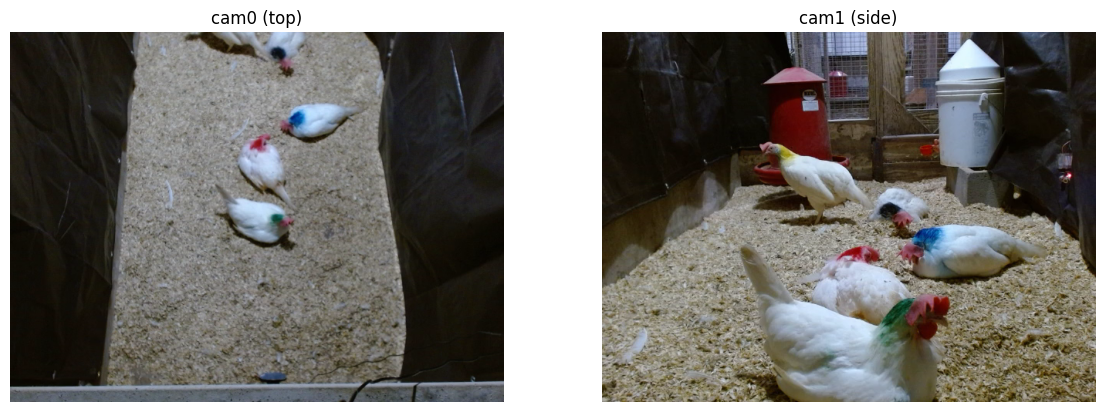

In [7]:
# Grab one frame from each video at FRAME_IDX.
def grab(path, idx):
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"could not read frame {idx} from {path}")
    return frame

frame0 = grab(CAM0, FRAME_IDX)   # cam0 (top-down)
frame1 = grab(CAM1, FRAME_IDX)   # cam1 (side)
print("cam0", frame0.shape[:2], " cam1", frame1.shape[:2])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)); ax[0].set_title("cam0 (top)"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)); ax[1].set_title("cam1 (side)"); ax[1].axis("off")
plt.show()

## 2. Confident hen detections

Run the detection model on each frame and draw the hen boxes above the confidence threshold (`CONF`).

cam0 hens: 5   cam1 hens: 5


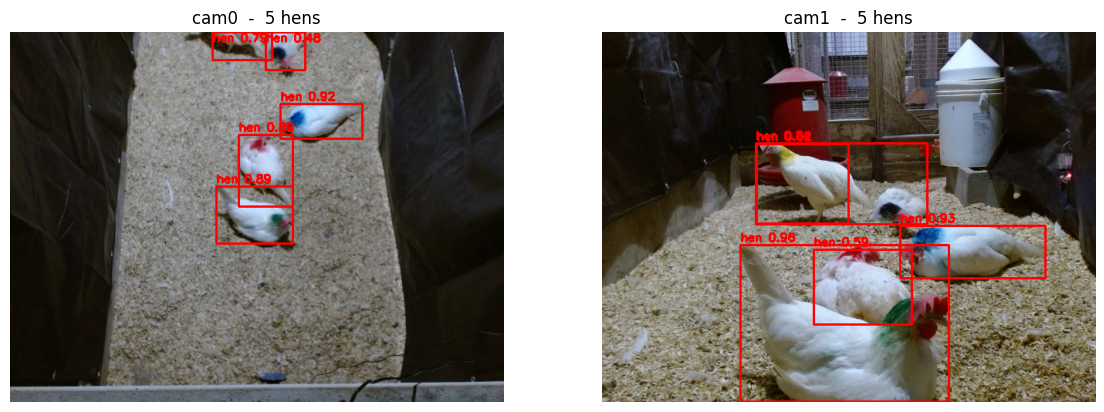

In [8]:
# Detect hens in each frame and draw the confident detections.
def detect_hens(frame):
    r = det.predict(frame, conf=CONF, verbose=False)[0]
    hens = []
    if r.boxes is not None:
        cls = r.boxes.cls.cpu().numpy().astype(int)
        xyxy = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
        for i in range(len(xyxy)):
            if cls[i] == HEN_CLASS:
                hens.append((xyxy[i], float(conf[i])))
    return hens

def annotate(frame, hens):
    out = frame.copy()
    for box, c in hens:
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(out, f"hen {c:.2f}", (x1, max(12, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    return out

hens0 = detect_hens(frame0)
hens1 = detect_hens(frame1)
print(f"cam0 hens: {len(hens0)}   cam1 hens: {len(hens1)}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(annotate(frame0, hens0), cv2.COLOR_BGR2RGB))
ax[0].set_title(f"cam0  -  {len(hens0)} hens"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(annotate(frame1, hens1), cv2.COLOR_BGR2RGB))
ax[1].set_title(f"cam1  -  {len(hens1)} hens"); ax[1].axis("off")
plt.show()

## 3. Crops of the detected hens

Each confident hen detection above is cropped (with a small padding margin). These crops are the inputs the pose model will run on.

total crops: 10


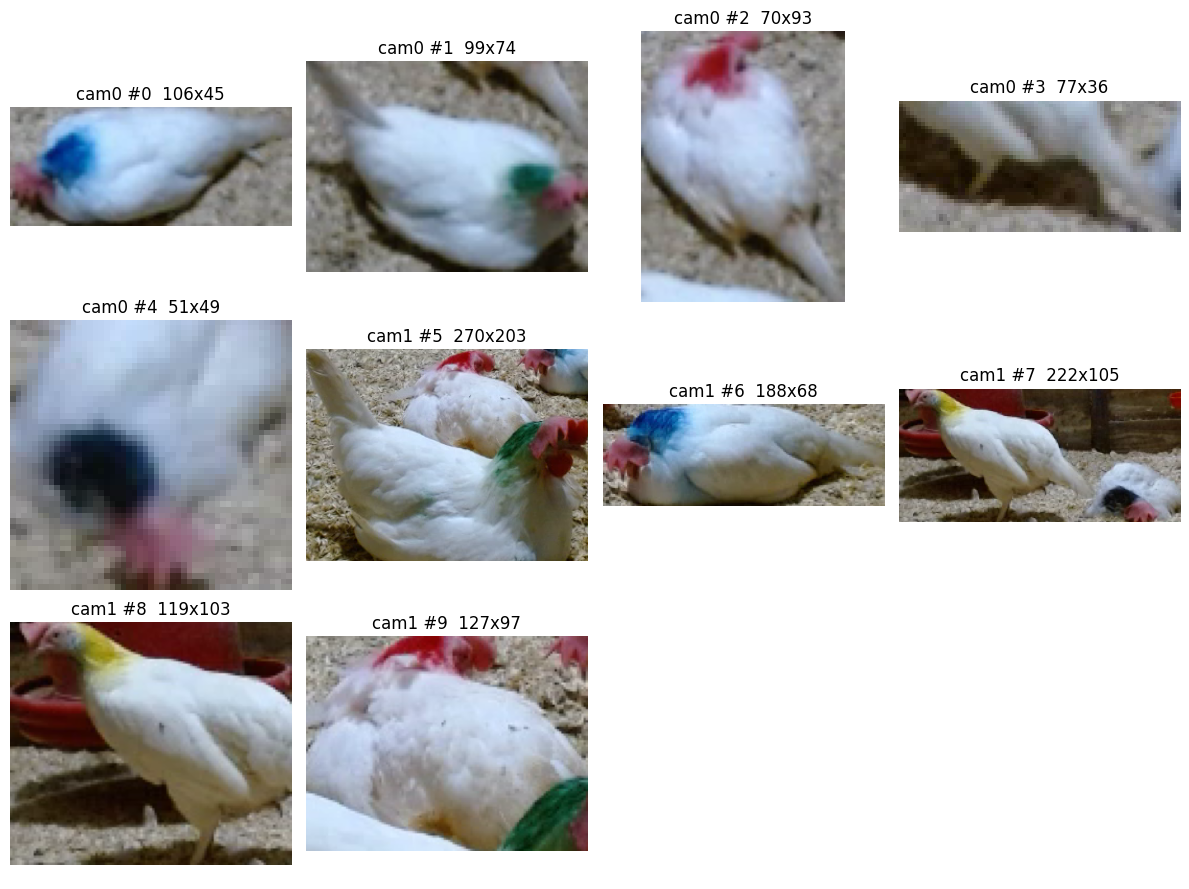

In [9]:
# Crop each detected hen (with padding) and show all crops.
def crop_hen(frame, box, pad=CROP_PAD):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    cx1, cy1 = int(max(0, x1 - pad * bw)), int(max(0, y1 - pad * bh))
    cx2, cy2 = int(min(w, x2 + pad * bw)), int(min(h, y2 + pad * bh))
    return frame[cy1:cy2, cx1:cx2]

crops = [("cam0", crop_hen(frame0, b)) for b, _ in hens0] + \
        [("cam1", crop_hen(frame1, b)) for b, _ in hens1]
print("total crops:", len(crops))

cols = min(4, max(1, len(crops)))
rows = max(1, (len(crops) + cols - 1) // cols)
fig, ax = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
ax = np.atleast_1d(ax).ravel()
for i, (cam, c) in enumerate(crops):
    ax[i].imshow(cv2.cvtColor(c, cv2.COLOR_BGR2RGB))
    ax[i].set_title(f"{cam} #{i}  {c.shape[1]}x{c.shape[0]}"); ax[i].axis("off")
for j in range(len(crops), len(ax)):
    ax[j].axis("off")
plt.tight_layout(); plt.show()

## 4. Pose on the crops

Run the pose model on each detected-hen crop. This is the point of the notebook: it lets us judge, on real 640x480 video frames, whether pose on per-hen crops localizes the ten keypoints well — the basis for the crop-based pose path in the pipeline.

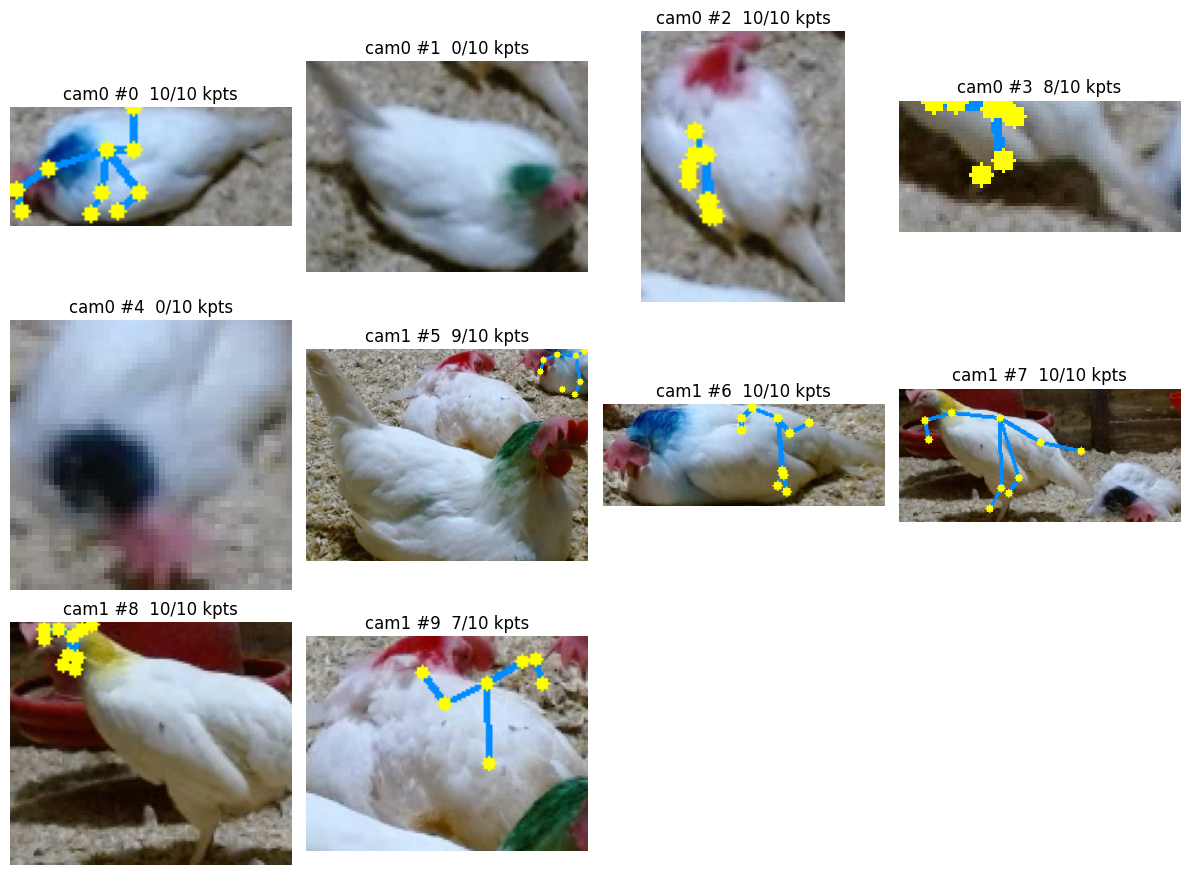

In [10]:
# Run the pose model on each crop and draw the predicted skeleton.
SKELETON = [(9, 8), (8, 6), (6, 7), (7, 0), (0, 1), (7, 2), (7, 3), (2, 4), (3, 5)]

def pose_on_crop(crop, kp_conf=0.25):
    r = pose.predict(crop, conf=0.25, verbose=False)[0]
    out = crop.copy()
    if r.keypoints is None or r.boxes is None or len(r.boxes) == 0:
        return out, 0
    k = r.keypoints.data.cpu().numpy()
    kp = k[int(r.boxes.conf.cpu().numpy().argmax())]   # most confident hen in the crop
    for a, c in SKELETON:
        if kp[a, 2] > kp_conf and kp[c, 2] > kp_conf:
            cv2.line(out, (int(kp[a, 0]), int(kp[a, 1])), (int(kp[c, 0]), int(kp[c, 1])), (255, 140, 0), 2)
    nvis = 0
    for j in range(len(kp)):
        if kp[j, 2] > kp_conf:
            cv2.circle(out, (int(kp[j, 0]), int(kp[j, 1])), 3, (0, 255, 255), -1)
            nvis += 1
    return out, nvis

fig, ax = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
ax = np.atleast_1d(ax).ravel()
for i, (cam, c) in enumerate(crops):
    out, nvis = pose_on_crop(c)
    ax[i].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax[i].set_title(f"{cam} #{i}  {nvis}/10 kpts"); ax[i].axis("off")
for j in range(len(crops), len(ax)):
    ax[j].axis("off")
plt.tight_layout(); plt.show()

Notes:
From this experiment I can see that the pose model is  stuck to a specific structure and doesn't easily shape to the various